# Coordinate-aware forward and inverse binning analysis
This notebook evaluates $X\leftrightarrow B(X)$, $B(X)\leftrightarrow INB(X)$, and $X\leftrightarrow INB(X)$ separately. Metrics use m/z matching; a common axis is created only for display.

In [13]:
import os
from pathlib import Path
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
root = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'pyproject.toml').is_file())
os.chdir(root)
from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.binning import BinningAnalysis
from msi_autoencoder_wrapper.binners.binners_manager import BinnerManager
from msi_autoencoder_wrapper.visualization import resolve_theme


## Load the configured MSI workspace and choose a reproducible cohort

In [14]:
wrapper = MSIAutoEncoderWrapper(project_path='workspace')
image_path = root / 'workspace/datasets/kidney-pilot-v2/kidney-pilot-v2.imzML'
wrapper.context_manager.set_reader('PyImzMLReader', str(image_path))
wrapper.context_manager.set_binner('LinearBinning', str(image_path), bin_step=0.01)
wrapper.context_manager.set_inverse_binner('TopPeaksInverseBinner', str(image_path), max_bins=500, window_size=2)
wrapper.workspace.set_active_image(str(image_path))
reader, configured_binner = wrapper.active_context.reader, wrapper.active_context.binner
dataset_size = reader.GetNumberOfSpectra()
owner = SimpleNamespace(reader=reader, binner=configured_binner, context=wrapper.active_context, theme=resolve_theme(None), default_model_name='binning', models={'binning': SimpleNamespace(dataset=range(dataset_size))})
owner.selected_ids = lambda ids, dataset: np.arange(len(dataset), dtype=np.int64) if ids is None else np.asarray(ids, dtype=np.int64)
analysis = SimpleNamespace(binning=BinningAnalysis(owner), reader=reader, binner=configured_binner, context=wrapper.active_context, dataset=range(dataset_size), theme=owner.theme)
rng = np.random.default_rng(1912)
SAMPLE_COUNT = 8  # Increase for the final dataset-wide run after validating the configuration.
spectrum_ids = np.sort(rng.choice(dataset_size, size=min(SAMPLE_COUNT, dataset_size), replace=False))
BinnerManager.discover_strategies()
spectrum_ids[:10], len(spectrum_ids)


2026-08-02 15:53:03,808 | INFO     | msi_autoencoder_wrapper.core.wrapper:73 | MSIAutoEncoderWrapper: Anchoring processing device state: cpu
2026-08-02 15:53:03,809 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:50 | Enforcing automatic module discovery for reader and binner registries.
2026-08-02 15:53:03,811 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.
2026-08-02 15:53:03,813 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-08-02 15:53:03,814 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 5 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-08-02 15:53:03,816 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 13 implementatio

(array([ 116, 1455, 2158, 3818, 4528, 4804, 5486, 5713]), 8)

## Configure and inspect every inverse strategy

In [15]:
forward = analysis.binner
inverse_binners = {
 'threshold': BinnerManager.get_inverse_binner('ThresholdInverseBinner', binner=forward, threshold_strategy='relative_to_max', threshold_options={'scale': 0.01}, max_bins=500),
 'cumulative_mass': BinnerManager.get_inverse_binner('CumulativeMassInverseBinner', binner=forward, retained_fraction=0.99, max_bins=500),
 'peak_centroid': BinnerManager.get_inverse_binner('PeakRegionInverseBinner', binner=forward, peak_threshold_strategy='relative_to_max', peak_threshold_options={'scale': 0.01}, region_strategy='relative_height', region_options={'relative_height': 0.5}, reduction_strategy='centroid', max_peaks=500, min_peak_distance=2),
}
sample_x, sample_y = analysis.reader.GetSpectrum(int(spectrum_ids[0]))
sample_forward = forward(xs=sample_x, ys=sample_y)
pd.DataFrame({name: inverse(sample_forward)[1] for name, inverse in inverse_binners.items()}).describe()


,threshold,cumulative_mass,peak_centroid
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


## Three comparisons × raw/TIC/max normalization × coordinate-aware metrics

In [16]:
all_records = []
all_summaries = []
for inverse_name, inverse in inverse_binners.items():
    records = analysis.binning.records(spectrum_ids, tolerance=0.01, tolerance_unit='Da', matching_strategy='local_mass', normalizations=('raw','tic','max'), inverse_binner=inverse)
    all_records.extend({'inverse_binner': inverse_name, **record} for record in records)
    summary = analysis.binning.metric_summaries(spectrum_ids, tolerance=0.01, tolerance_unit='Da', matching_strategy='local_mass', normalizations=('raw','tic','max'), inverse_binner=inverse)
    all_summaries.extend({'inverse_binner': inverse_name, **record} for record in summary)
records_df = pd.DataFrame(all_records)
summaries_df = pd.DataFrame(all_summaries)
summaries_df.query("normalization == 'raw' and metric in ['localization_mae_da','peak_recall','tic_relative_error','wasserstein']")


,inverse_binner,comparison,normalization,metric,count,mean,std,min,q25,q50,q75,q90,q95,q99,median,max
0,threshold,binned_original,raw,localization_mae_da,8.0,0.002511,0.000000,0.002511,0.002511,0.002511,0.002511,0.002511,0.002511,0.002511,0.002511,0.002511
14,threshold,binned_original,raw,peak_recall,8.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
18,threshold,binned_original,raw,tic_relative_error,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
21,threshold,binned_original,raw,wasserstein,5.0,0.002195,0.000043,0.002133,0.002172,0.002187,0.002227,0.002245,0.002251,0.002256,0.002187,0.002257
66,threshold,inverse_binned,raw,localization_mae_da,5.0,0.006223,0.000023,0.006181,0.006218,0.006230,0.006243,0.006244,0.006244,0.006244,0.006230,0.006244
80,threshold,inverse_binned,raw,peak_recall,8.0,0.001092,0.000847,0.000000,0.000000,0.001691,0.001764,0.001796,0.001803,0.001808,0.001691,0.001809
84,threshold,inverse_binned,raw,tic_relative_error,8.0,0.134960,0.105024,0.000000,0.000000,0.201707,0.221994,0.227659,0.228249,0.228721,0.201707,0.228840
87,threshold,inverse_binned,raw,wasserstein,5.0,13.867340,1.450041,11.982100,12.592924,14.062995,14.677074,15.483795,15.752702,15.967828,14.062995,16.021609
132,threshold,inverse_original,raw,localization_mae_da,5.0,0.002315,0.000095,0.002197,0.002248,0.002290,0.002380,0.002429,0.002445,0.002458,0.002290,0.002462
146,threshold,inverse_original,raw,peak_recall,8.0,0.069275,0.053739,0.000000,0.000000,0.106870,0.111832,0.113893,0.114962,0.115817,0.106870,0.116031


## Histogram and ECDF per comparison (never mix normalizations implicitly)

(<Figure size 2160x600 with 3 Axes>,
 array([<Axes: title={'center': 'binned_original'}, xlabel='peak_recall', ylabel='ECDF'>,
        <Axes: title={'center': 'inverse_binned'}, xlabel='peak_recall', ylabel='ECDF'>,
        <Axes: title={'center': 'inverse_original'}, xlabel='peak_recall', ylabel='ECDF'>],
       dtype=object))

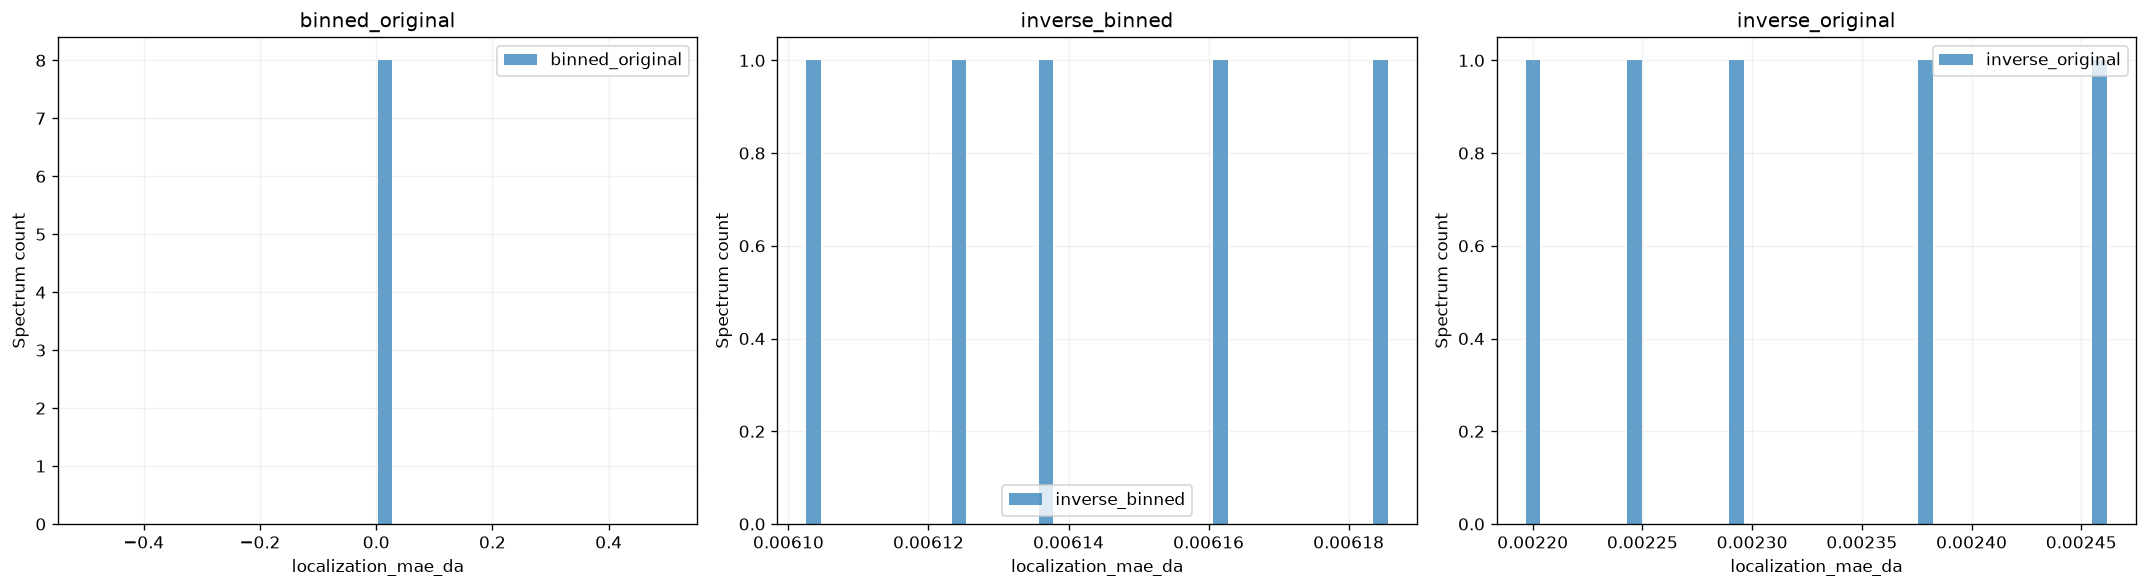

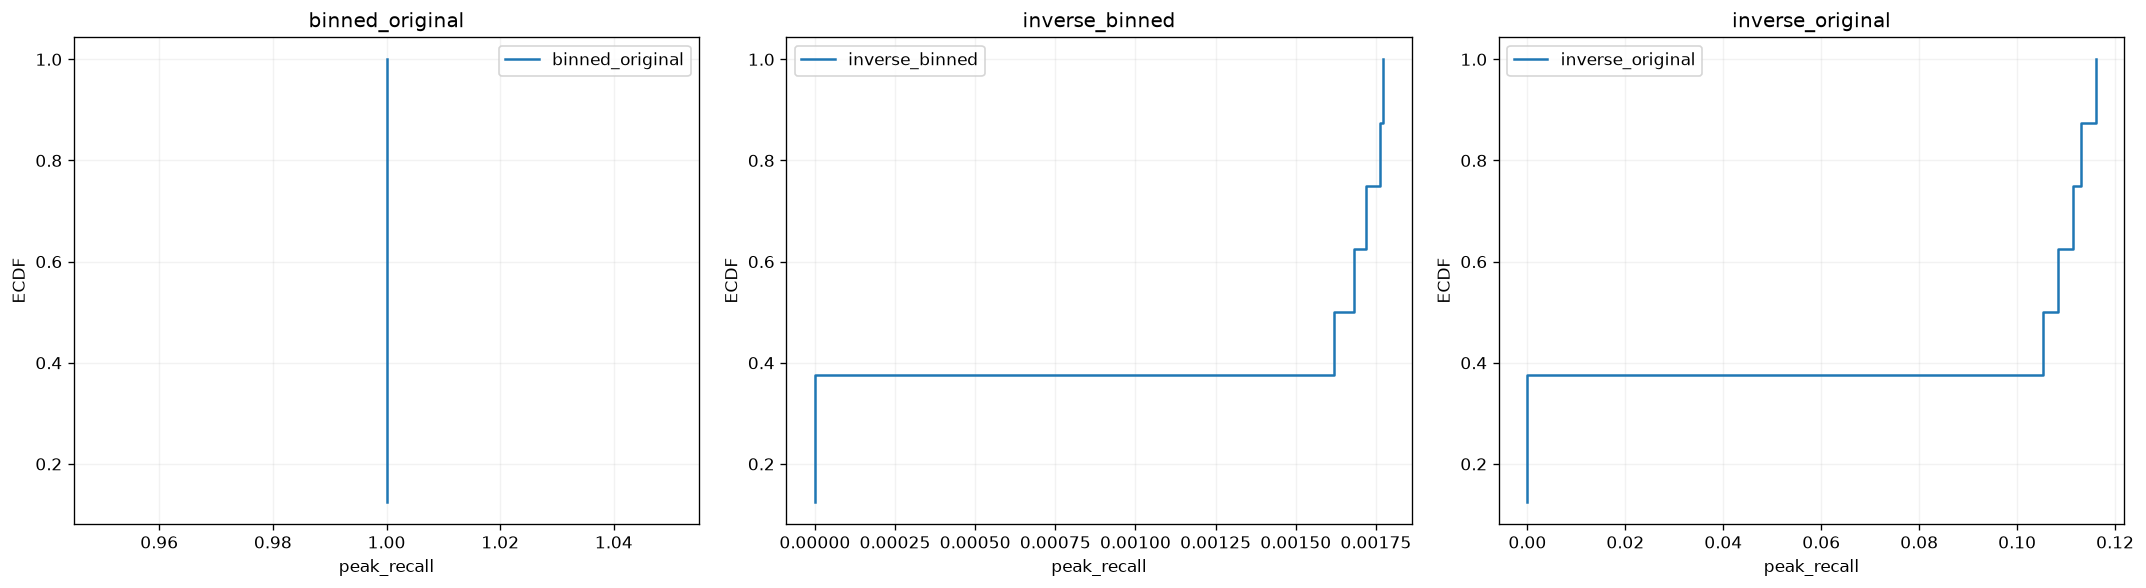

In [17]:
DISTRIBUTION_PARAMETERS = dict(spectrum_ids=spectrum_ids, tolerance=0.01, tolerance_unit='Da', matching_strategy='local_mass', inverse_binner=inverse_binners['peak_centroid'])
analysis.binning.plot_metric_distributions(metric='localization_mae_da', normalization='raw', kind='histogram', bins=40, **DISTRIBUTION_PARAMETERS)
analysis.binning.plot_metric_distributions(metric='peak_recall', normalization='tic', kind='ecdf', bins=40, **DISTRIBUTION_PARAMETERS)


## Best, median, and worst spectra, followed by mirrored native-coordinate views

In [18]:
RANKING_PARAMETERS = dict(comparison='inverse_original', normalization='raw', spectrum_ids=spectrum_ids, inverse_binner=inverse_binners['peak_centroid'], tolerance=0.01, tolerance_unit='Da', matching_strategy='local_mass')
ranking_metrics = ('localization_mae_da','wasserstein','cosine_similarity','tic_relative_error','peak_recall')
ranked_figure, ranked_axes = analysis.binning.plot_ranked_spectra(metrics=ranking_metrics, **RANKING_PARAMETERS)


AttributeError: 'BinningAnalysis' object has no attribute 'plot_ranked_spectra'

## Forward-resolution sweep and separate trade-off plots

In [19]:
FORWARD_SWEEP_PARAMETERS = dict(bin_steps=[0.010,0.011,0.012,0.013,0.015,0.020], spectrum_ids=spectrum_ids, baseline_step=0.010, tolerance=0.01, tolerance_unit='Da', matching_strategy='local_mass', normalizations=('raw','tic','max'))
forward_sweep = analysis.binning.forward_sweep(**FORWARD_SWEEP_PARAMETERS)
forward_sweep_df = pd.DataFrame(forward_sweep)
for normalization in ('raw','tic','max'):
    for metric in ('localization_mae_da','peak_recall','wasserstein','cosine_similarity','tic_relative_error'):
        analysis.binning.plot_tradeoff(forward_sweep, metric=metric, x='bin_step', normalization=normalization)
forward_sweep_df.head()


IndexError: boolean index did not match indexed array along axis 0; size of axis is 110007 but size of corresponding boolean axis is 100007

## Error dependence on spectrum properties and inverse compression diagnostics

,input_bin_count,valid_bin_count,selected_bin_count,output_peak_count,retained_raw_intensity_fraction,retained_mass_fraction,compression_ratio,threshold_value,target_fraction,target_fraction_reached,detected_peak_count,selected_region_count,merged_region_count,mean_region_width,max_region_width
threshold,110007.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cumulative_mass,110007,0,0,0,0.0,0.0,0.0,None,0.99,False,NaN,NaN,NaN,NaN,NaN
peak_centroid,110007.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0


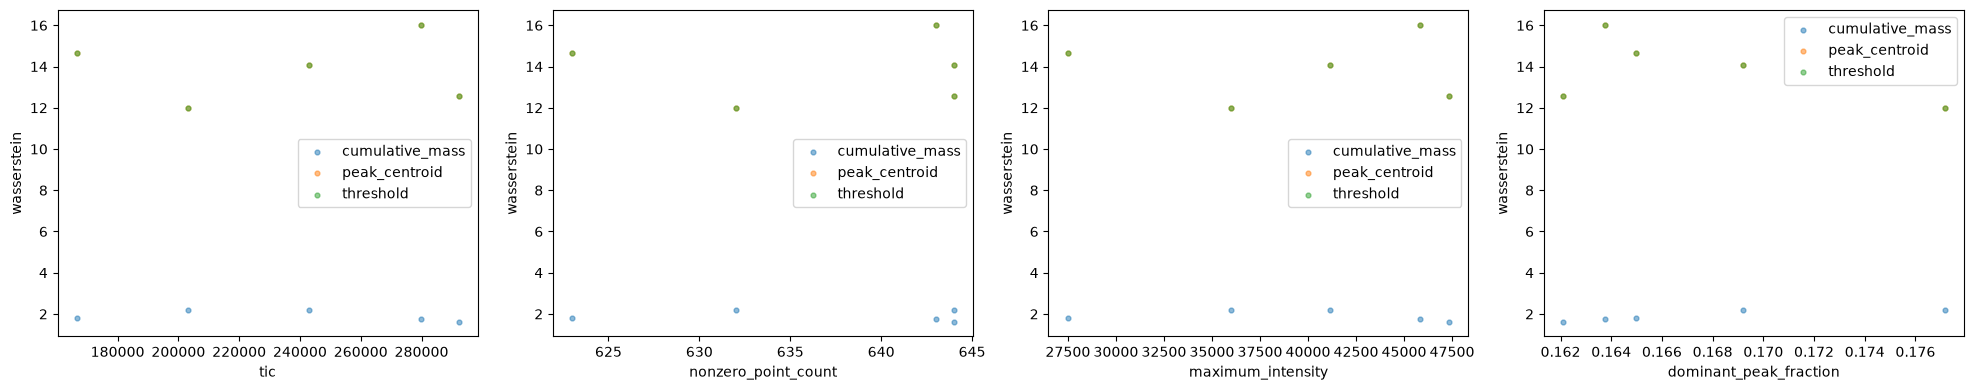

In [20]:
selected = records_df.query("comparison == 'inverse_original' and normalization == 'raw' and metric == 'wasserstein'")
fig, axes = plt.subplots(1,4,figsize=(20,4))
for ax, property_name in zip(axes, ('tic','nonzero_point_count','maximum_intensity','dominant_peak_fraction')):
    for name, group in selected.groupby('inverse_binner'): ax.scatter(group[property_name], group.value, s=12, alpha=.5, label=name)
    ax.set(xlabel=property_name, ylabel='wasserstein'); ax.legend()
fig.tight_layout()
diagnostics = pd.DataFrame({name: inverse.get_last_diagnostics() for name, inverse in inverse_binners.items()}).T
diagnostics


## m/z localization profile and spatial metric maps

(<Figure size 1440x840 with 2 Axes>,
 <Axes: title={'left': 'Inverse-original Wasserstein | raw | local_mass | 0.01 Da'}>)

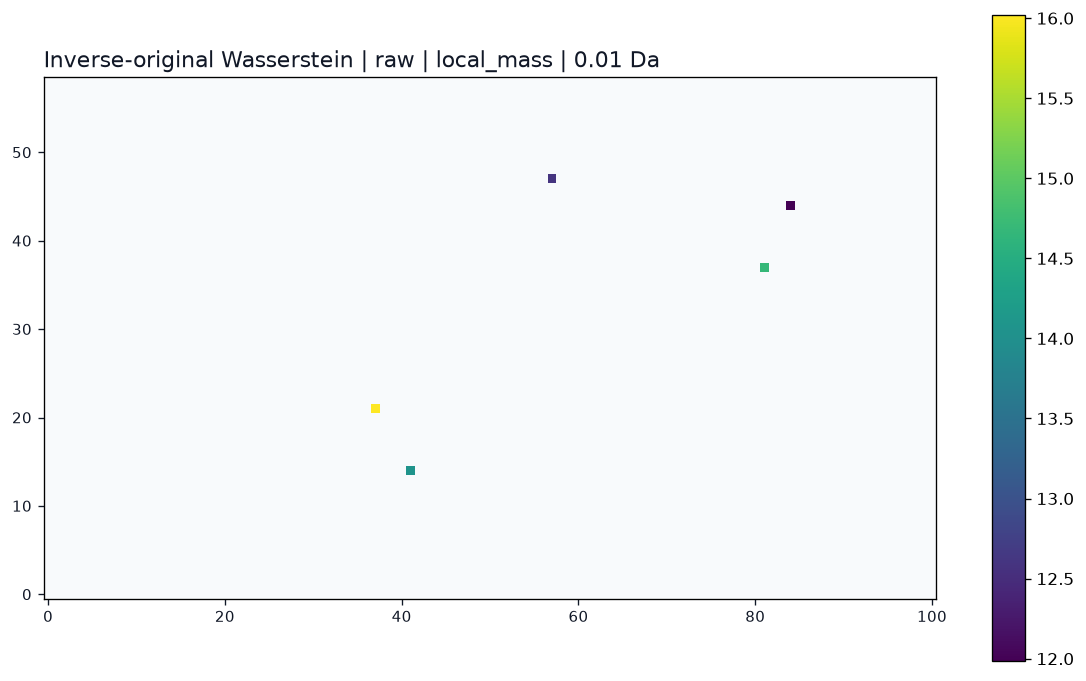

In [21]:
spatial_metric = records_df.query("inverse_binner == 'peak_centroid' and comparison == 'inverse_original' and normalization == 'raw' and metric == 'wasserstein'").set_index('spectrum_id').value
full_values = np.full(len(analysis.dataset), np.nan)
full_values[spatial_metric.index.to_numpy(dtype=int)] = spatial_metric.to_numpy()
spatial = analysis.reader.MapSpectrumValuesToImage(full_values)
from msi_autoencoder_wrapper.visualization.spatial import plot_spatial_image
plot_spatial_image(spatial.values, title='Inverse-original Wasserstein | raw | local_mass | 0.01 Da', theme=analysis.theme)


## Ion-image comparison from original and inverse spectra

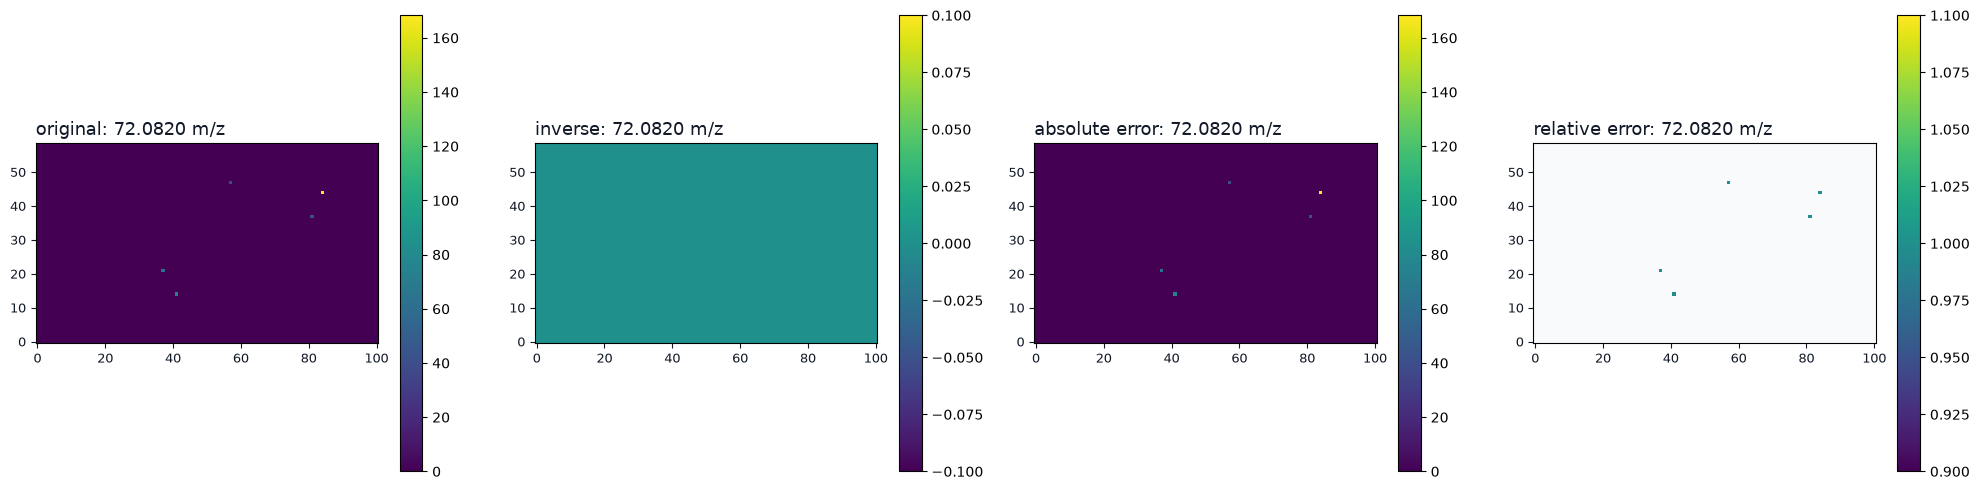

In [22]:
mz = float(sample_x[np.argmax(sample_y)]); tolerance = 0.01
original_values = np.zeros(len(analysis.dataset)); inverse_values = np.zeros(len(analysis.dataset))
for spectrum_id in spectrum_ids:
    rx, ry, ix, iy = analysis.binning.representations(int(spectrum_id), inverse_binner=inverse_binners['peak_centroid'])['inverse_original']
    original_values[spectrum_id] = np.sum(ry[np.abs(rx-mz) <= tolerance]); inverse_values[spectrum_id] = np.sum(iy[np.abs(ix-mz) <= tolerance])
original_image = analysis.reader.MapSpectrumValuesToImage(original_values).values
inverse_image = analysis.reader.MapSpectrumValuesToImage(inverse_values).values
absolute_error = np.abs(original_image-inverse_image)
relative_error = np.divide(absolute_error, original_image, out=np.full_like(absolute_error,np.nan), where=original_image!=0)
fig, axes = plt.subplots(1,4,figsize=(20,5))
for ax, image, title in zip(axes,(original_image,inverse_image,absolute_error,relative_error),('original','inverse','absolute error','relative error')): plot_spatial_image(image,title=f'{title}: {mz:.4f} m/z',ax=ax,theme=analysis.theme)
fig.tight_layout()
